# Chapter 22 Lab — Multiple Comparisons

In this lab you will *experience* the multiple comparisons problem instead of just reading about it. We simulate thousands of statistical tests where the ground truth is known, then compare what uncorrected thresholds, Bonferroni (FWER) correction, Benjamini–Hochberg FDR correction, and a permutation-based max-statistic threshold each do to sensitivity and false positives.

**How to run this notebook.** Everything is simulated — no downloads, no brain data required — and every cell runs in a few seconds. You can run it in the browser (via the rocket icon), open it in Colab, or download it and run it locally with any scientific Python installation (NumPy, SciPy, Matplotlib, statsmodels). It accompanies the [Multiple Comparisons chapter page](../ch22-multiple-comparisons.md).

**▶ This notebook is interactive.** Click the **⏻ power icon** at the top right of this page to run it in your browser — no installation needed (the kernel takes ~30–60 s to start the first time). Then run cells **top to bottom**, starting with the first code cell below: later cells depend on the imports and variables defined earlier, and will error if you skip ahead.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.ndimage import gaussian_filter1d
from statsmodels.stats.multitest import multipletests

rng = np.random.default_rng(42)

## Part 1 — The multiple comparisons problem: 10,000 null tests

Imagine a "brain" of 10,000 voxels in which **nothing is truly active**. We scan 30 subjects of pure noise and run a one-sample t-test at every voxel, exactly as a group analysis would. How many voxels reach $p < .05$?

In [2]:
n, k = 30, 10000                      # subjects, tests (voxels)

dat = rng.standard_normal((n, k))     # pure noise: null is true everywhere
tvals, p = stats.ttest_1samp(dat, 0)  # one-sample t-test at each voxel

nsig = (p < .05).sum()
print(f'{nsig} of {k} null tests are "significant" at p < .05 '
      f'(expected ~{int(.05 * k)})')

529 of 10000 null tests are "significant" at p < .05 (expected ~500)


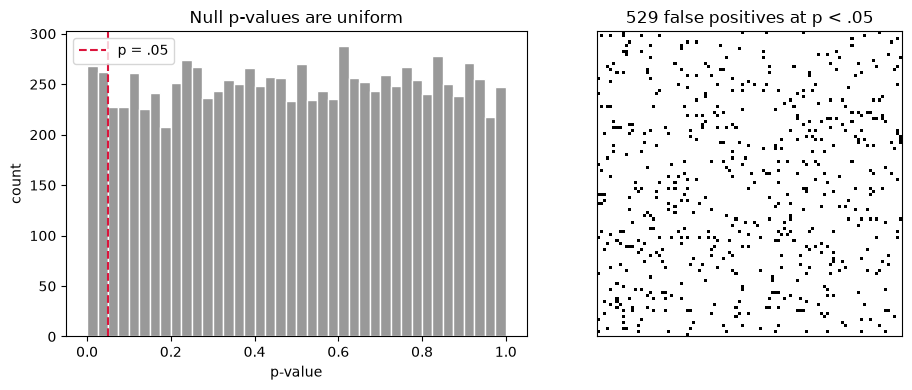

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# p-values under the null are uniform on [0, 1]
axes[0].hist(p, bins=40, color='0.6', edgecolor='w')
axes[0].axvline(.05, color='crimson', ls='--', label='p = .05')
axes[0].set(xlabel='p-value', ylabel='count', title='Null p-values are uniform')
axes[0].legend()

# arrange the 10,000 tests as a 100 x 100 "slice" and mark the false positives
axes[1].imshow((p < .05).reshape(100, 100), cmap='gray_r', interpolation='nearest')
axes[1].set(title=f'{nsig} false positives at p < .05', xticks=[], yticks=[])

plt.tight_layout()
plt.show()

Roughly 500 voxels are "significant" — and every single one is a false positive, scattered salt-and-pepper across the image. This is what an uncorrected $p < .05$ map of a null contrast looks like. A real 2-mm brain mask has ~240,000 voxels, so the same logic predicts ~12,000 false positive voxels per map.

## Part 2 — Bonferroni (FWER) and Benjamini–Hochberg (FDR)

Two philosophies of correction:

- **Bonferroni** controls the *family-wise error rate* — the probability of **any** false positive — by testing each voxel at $\alpha / m$.
- **Benjamini–Hochberg (BH)** controls the *false discovery rate* — the expected **proportion** of false positives among significant voxels. Rank the p-values $p_{(1)} \le \dots \le p_{(m)}$ and find the largest rank $r$ with

$$p_{(r)} \le \frac{r}{m}\,q,$$

then reject all tests with $p \le p_{(r)}$.

First, apply both to the pure-noise data. A valid correction should produce many fewer false positives: one in every 20 simulation runs for FWER (a 5% chance of *any* false positive in the family of tests), and with pure null data FDR control is equivalent to FWER control, so almost nothing survives.

In [4]:
alpha = 0.05

n_unc  = (p < alpha).sum()
n_bonf = (p < alpha / k).sum()
n_fdr  = multipletests(p, alpha=alpha, method='fdr_bh')[0].sum()

print(f'Pure noise, {k} tests:')
print(f'  Uncorrected p < .05 : {n_unc:5d} significant (all false positives!)')
print(f'  Bonferroni          : {n_bonf:5d} significant')
print(f'  FDR (BH)            : {n_fdr:5d} significant')

Pure noise, 10000 tests:
  Uncorrected p < .05 :   529 significant (all false positives!)
  Bonferroni          :     0 significant
  FDR (BH)            :     0 significant


Both corrections do their job under the global null: with no true signal, FDR control is equivalent to FWER control, and (almost always) nothing survives.

## Part 3 — With signal present: the sensitivity/specificity tradeoff

Corrections only become interesting when there is something to find. Following the simulations in the book author's `fdr_sims_playground.m` ([FMRI_simulations repo](https://github.com/canlab/FMRI_simulations)), we now plant a true effect of $d = 0.5$ in **10% of the 10,000 tests** and scan $n = 50$ subjects. For every method we can score, against ground truth:

- **TPR** (sensitivity): fraction of truly active tests detected
- **FPR**: fraction of null tests falsely detected
- **observed FDR**: fraction of *detections* that are false

In [5]:
n, k, d = 50, 10000, 0.5
numtrue = k // 10                              # 1,000 truly active tests
istrue = np.arange(k) < numtrue
mu = np.where(istrue, d, 0.0)

dat = mu + rng.standard_normal((n, k))
tvals, p = stats.ttest_1samp(dat, 0)

rej_fdr = multipletests(p, alpha=alpha, method='fdr_bh')[0]

def score(sig):
    tpr = (sig & istrue).sum() / numtrue
    fpr = (sig & ~istrue).sum() / (k - numtrue)
    fdr_obs = (sig & ~istrue).sum() / max(sig.sum(), 1)
    return sig.sum(), tpr, fpr, fdr_obs

print(f'{"method":<14s}{"n sig":>7s}{"TPR":>8s}{"FPR":>9s}{"obs FDR":>10s}')
for name, sig in [('Uncorrected', p < alpha),
                  ('Bonferroni',  p < alpha / k),
                  ('FDR (BH)',    rej_fdr)]:
    ns, tpr, fpr, fdr_obs = score(sig)
    print(f'{name:<14s}{ns:7d}{tpr:8.2f}{fpr:9.4f}{fdr_obs:10.3f}')

method          n sig     TPR      FPR   obs FDR
Uncorrected      1358    0.92   0.0487     0.323
Bonferroni         84    0.08   0.0000     0.000
FDR (BH)          713    0.68   0.0038     0.048


Read the table across the rows. **Uncorrected** finds the most true effects, but a large fraction of its "discoveries" are false — you could not say *which* voxels to believe. **Bonferroni** keeps the map almost perfectly clean but misses the majority of true effects. **BH-FDR** sits in between: it keeps the false fraction of discoveries near the nominal 5% while retaining far more sensitivity than Bonferroni.

### Visualizing the BH step-up threshold

The BH procedure has an elegant geometric picture: plot the sorted p-values against their rank $r$, draw the line $q \cdot r / m$, and reject everything up to the **last crossing point**. Because the threshold moves with the p-value distribution, more signal ⇒ more small p-values ⇒ a more generous threshold — the procedure is *adaptive*.

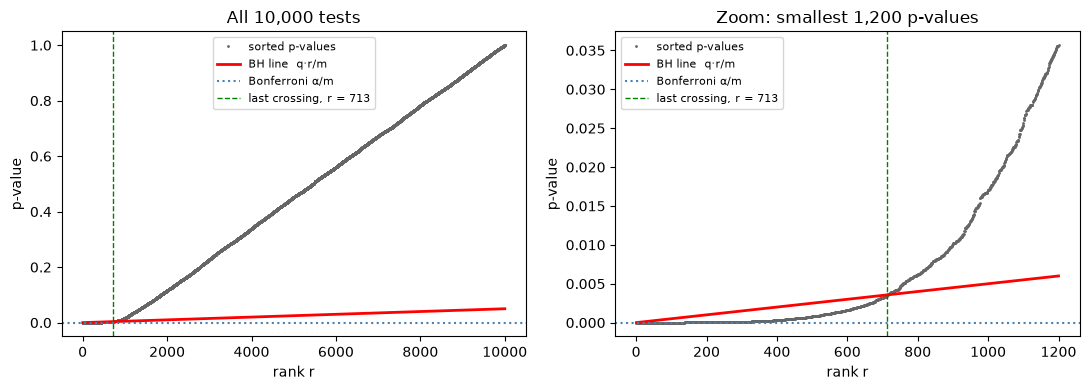

BH threshold: reject the 713 tests with p <= 0.00352
Bonferroni threshold: p <= 5.00e-06


In [6]:
psort = np.sort(p)
ranks = np.arange(1, k + 1)
bh_line = alpha * ranks / k

below = psort <= bh_line
r_star = np.max(np.nonzero(below)[0]) + 1 if below.any() else 0
p_thresh = psort[r_star - 1] if r_star else 0.0

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, nshow in zip(axes, [k, 1200]):
    ax.plot(ranks[:nshow], psort[:nshow], '.', ms=2, color='0.4',
            label='sorted p-values')
    ax.plot(ranks[:nshow], bh_line[:nshow], 'r-', lw=2,
            label='BH line  q·r/m')
    ax.axhline(alpha / k, color='steelblue', ls=':', label='Bonferroni α/m')
    if r_star <= nshow:
        ax.axvline(r_star, color='green', ls='--', lw=1,
                   label=f'last crossing, r = {r_star}')
    ax.set(xlabel='rank r', ylabel='p-value')
    ax.legend(fontsize=8)
axes[0].set_title('All 10,000 tests')
axes[1].set_title('Zoom: smallest 1,200 p-values')
plt.tight_layout()
plt.show()

print(f'BH threshold: reject the {r_star} tests with p <= {p_thresh:.5f}')
print(f'Bonferroni threshold: p <= {alpha/k:.2e}')

The zoomed panel (right) shows the mechanics: the cloud of small p-values from the true effects dips below the red BH line, and the crossing point sets the threshold — orders of magnitude more liberal than the flat Bonferroni line, yet still controlling the false discovery *rate*.

### How stable is the control? Repeating the experiment

FDR control is a statement about *expectations across experiments*. Any single study's observed FDR can be higher or lower. Let's replicate the simulation 20 times and look at the spread.

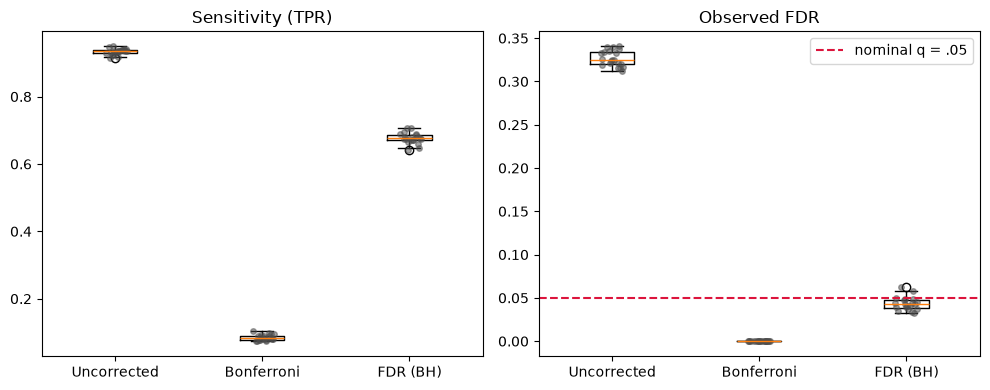

In [7]:
niter = 20
methods = ['Uncorrected', 'Bonferroni', 'FDR (BH)']
tpr = np.zeros((niter, 3))
fdr_obs = np.zeros((niter, 3))

for i in range(niter):
    dat_i = mu + rng.standard_normal((n, k))
    _, p_i = stats.ttest_1samp(dat_i, 0)
    sigs = [p_i < alpha,
            p_i < alpha / k,
            multipletests(p_i, alpha=alpha, method='fdr_bh')[0]]
    for j, sig in enumerate(sigs):
        tpr[i, j] = (sig & istrue).sum() / numtrue
        fdr_obs[i, j] = (sig & ~istrue).sum() / max(sig.sum(), 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, vals, title, hline in [(axes[0], tpr, 'Sensitivity (TPR)', None),
                               (axes[1], fdr_obs, 'Observed FDR', 0.05)]:
    ax.boxplot(list(vals.T), tick_labels=methods)
    jitter = rng.uniform(-.08, .08, niter)
    for j in range(3):
        ax.plot(np.full(niter, j + 1) + jitter, vals[:, j], 'o',
                color='0.3', alpha=.5, ms=4)
    if hline is not None:
        ax.axhline(hline, color='crimson', ls='--', label='nominal q = .05')
        ax.legend()
    ax.set_title(title)
plt.tight_layout()
plt.show()

Across replications, BH keeps the observed FDR scattered around (in fact, slightly below) the nominal 5%, with far higher sensitivity than Bonferroni. Uncorrected testing holds its FDR near 30% here only because a full 10% of tests are truly active — with sparser signal its discoveries become mostly noise.

## Part 4 — Permutation testing and the max-statistic (FWER) threshold

Parametric corrections need assumptions (independence for Bonferroni, Gaussian smoothness for random field theory). A **permutation test** instead builds the null distribution from the data itself. For a one-sample group test, under the null each subject's effect image is symmetric around zero, so we can randomly **sign-flip whole subject images**. Because entire images are flipped together, the spatial correlation structure is preserved automatically.

To control the FWER we track the **maximum |t| across all voxels** in each permutation: the 95th percentile of that max distribution is a threshold that any null voxel exceeds with only 5% probability — anywhere in the brain. On spatially *smooth* data this threshold adapts to the effective number of independent tests, where Bonferroni cannot.

In [8]:
n, k = 25, 4000
smooth_sigma = 3.0                      # spatial smoothness (voxels)

def smooth_noise(shape, sigma, rng):
    z = gaussian_filter1d(rng.standard_normal(shape), sigma, axis=-1)
    return z / z.std()                  # rescale to unit variance

# true signal: d = 0.8 in one contiguous "region" of 200 voxels
istrue = np.zeros(k, bool)
istrue[1800:2000] = True
mu = np.where(istrue, 0.8, 0.0)

dat = mu + smooth_noise((n, k), smooth_sigma, rng)

def tstat(X):
    return X.mean(0) / (X.std(0, ddof=1) / np.sqrt(X.shape[0]))

t_obs = tstat(dat)

# --- permutation max-|t| distribution (sign flipping) ---
nperm = 500
maxt = np.empty(nperm)
for i in range(nperm):
    signs = rng.choice([-1.0, 1.0], size=(n, 1))
    maxt[i] = np.abs(tstat(signs * dat)).max()

t_perm = np.quantile(maxt, 0.95)                    # FWER .05 threshold
t_bonf = stats.t.ppf(1 - 0.025 / k, n - 1)          # Bonferroni (two-tailed)

print(f'Permutation max-|t| threshold (FWER .05): t > {t_perm:.2f}')
print(f'Bonferroni threshold                    : t > {t_bonf:.2f}')
print(f'True voxels detected: permutation {int((np.abs(t_obs) > t_perm)[istrue].sum())}, '
      f'Bonferroni {int((np.abs(t_obs) > t_bonf)[istrue].sum())} (of {int(istrue.sum())})')
print(f'Null voxels detected: permutation {int((np.abs(t_obs) > t_perm)[~istrue].sum())}, '
      f'Bonferroni {int((np.abs(t_obs) > t_bonf)[~istrue].sum())}')

Permutation max-|t| threshold (FWER .05): t > 5.15
Bonferroni threshold                    : t > 5.48
True voxels detected: permutation 37, Bonferroni 20 (of 200)
Null voxels detected: permutation 0, Bonferroni 0


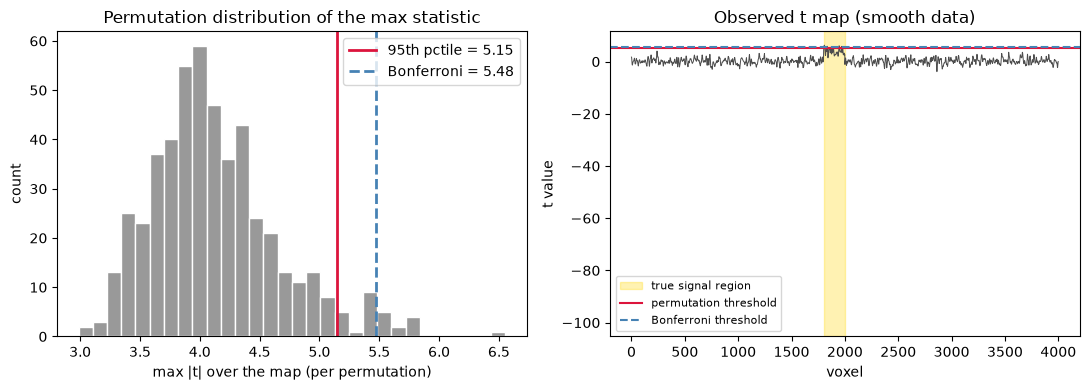

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(maxt, bins=30, color='0.6', edgecolor='w')
axes[0].axvline(t_perm, color='crimson', lw=2,
                label=f'95th pctile = {t_perm:.2f}')
axes[0].axvline(t_bonf, color='steelblue', ls='--', lw=2,
                label=f'Bonferroni = {t_bonf:.2f}')
axes[0].set(xlabel='max |t| over the map (per permutation)', ylabel='count',
            title='Permutation distribution of the max statistic')
axes[0].legend()

axes[1].plot(t_obs, color='0.3', lw=.7)
axes[1].axhspan(1800 * 0 - 100, 0, alpha=0)  # keep autoscale sane
axes[1].axvspan(1800, 2000, color='gold', alpha=.3, label='true signal region')
axes[1].axhline(t_perm, color='crimson', lw=1.5, label='permutation threshold')
axes[1].axhline(t_bonf, color='steelblue', ls='--', lw=1.5,
                label='Bonferroni threshold')
axes[1].set(xlabel='voxel', ylabel='t value', title='Observed t map (smooth data)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

Because the noise is spatially smooth, the effective number of independent tests is much smaller than 4,000 — and the permutation max-|t| threshold is correspondingly *lower* than Bonferroni's, buying extra detections while still controlling the FWER exactly. This is the core idea behind FSL's `randomise` and PALM, and it is why permutation methods are considered the gold standard for neuroimaging inference.

## Wrapping up

- Thousands of uncorrected tests **guarantee** false positives; an uncorrected $p<.05$ map of pure noise lights up ~5% of the brain.
- **Bonferroni / FWER** control makes any false positive unlikely, at a steep cost in sensitivity — and it ignores the spatial smoothness of fMRI data.
- **BH-FDR** controls the expected fraction of false *discoveries*, adapts to the amount of signal in the map, and offers a much better power/error balance for mapping studies.
- **Permutation max-statistic** thresholds control FWER exactly with almost no assumptions, adapting automatically to smoothness.

For how these choices interact with sample size and statistical power, continue to Chapter 29; for what a significant *cluster* does and does not tell you, revisit the chapter page.